## モデル作成

In [3]:
import pandas as pd

In [185]:
df_25 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/results.pickle')
df_24 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2024_results.pickle')
df_23 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2023_results.pickle')
df_22 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2022_results.pickle')
df_21 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2021_results.pickle')
df_20 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2020_results.pickle')
df_19 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2019_results.pickle')
df_18 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2018_results.pickle')
df_17 = pd.read_pickle('/Users/yoshizawakazuki/Kazuki_module/Horse/2017_results.pickle')

In [135]:
df_24

,着順,枠番,馬番,馬名,性齢,斤量,騎手,タイム,着差,単勝,人気,馬体重,調教師,course_len,weather,race_type,ground_state,date,horse_id,jockey_id
202406050911,1,3,6,クロワデュノール,牡2,56.0,北村友一,2:00.5,NaN,1.8,1.0,496(-8),[西] 斉藤崇史,2000,晴,芝,良,2024年12月28日,2022105102,01102
202406050911,2,1,1,ジョバンニ,牡2,56.0,松山弘平,2:00.8,2,19.1,6.0,484(0),[西] 杉山晴紀,2000,晴,芝,良,2024年12月28日,2022103995,01126
202406050911,3,6,11,ファウストラーゼン,牡2,56.0,杉原誠人,2:01.0,1.1/4,303.3,17.0,454(-2),[西] 西村真幸,2000,晴,芝,良,2024年12月28日,2022104218,01135
202406050911,4,8,16,ジュタ,牡2,56.0,坂井瑠星,2:01.2,1,26.5,8.0,510(+6),[西] 矢作芳人,2000,晴,芝,良,2024年12月28日,2022104813,01163
202406050911,5,2,4,クラウディアイ,牡2,56.0,西村淳也,2:01.4,1.1/2,67.2,13.0,432(+2),[西] 橋口慎介,2000,晴,芝,良,2024年12月28日,2022100099,01171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202408010111,14,7,15,ドーブネ,牡5,58.5,吉田隼人,1:35.1,3/4,7.4,4.0,482(+10),[西] 武幸四郎,1600,晴,芝,良,2024年01月06日,2019104896,01095
202408010111,15,6,12,ビューティフルデイ,牝6,55.0,西村淳也,1:35.2,3/4,81.9,14.0,450(-4),[東] 国枝栄,1600,晴,芝,良,2024年01月06日,2018103929,01171
202408010111,16,7,13,マテンロウオリオン,牡5,58.0,太宰啓介,1:35.4,1.1/4,31.1,12.0,488(+8),[西] 昆貢,1600,晴,芝,良,2024年01月06日,2019100965,01037
202408010111,17,3,6,シャイニーロック,牡8,57.0,酒井学,1:35.5,クビ,118.6,15.0,510(+2),[西] 佐々木晶,1600,晴,芝,良,2024年01月06日,2016103884,01034


In [186]:
# Concat 
df = pd.concat([df_25,df_24,df_23,df_22,df_21,df_20,df_19,df_18,df_17],axis=0)
len(df)

12744

In [120]:
df.head(5)

,着順,枠番,馬番,馬名,性齢,斤量,騎手,タイム,着差,単勝,人気,馬体重,調教師,course_len,weather,race_type,ground_state,date,horse_id,jockey_id
202506050111,1,3,3,ホーエリート,牝4,55.0,戸崎圭太,3:47.2,NaN,4.4,2.0,476(-6),[東] 田島俊明,3600,晴,芝,良,2025年12月06日,2021104855,05386
202506050111,2,3,4,マイネルカンパーナ,牡5,57.0,津村明秀,3:47.3,3/4,11.6,5.0,414(+2),[東] 青木孝文,3600,晴,芝,良,2025年12月06日,2020105798,01092
202506050111,3,5,7,クロミナンス,牡8,57.0,ルメール,3:47.3,ハナ,3.5,1.0,494(0),[東] 尾関知人,3600,晴,芝,良,2025年12月06日,2017105074,05339
202506050111,4,5,8,ブレイヴロッカー,セ5,57.0,荻野極,3:47.3,クビ,18.3,9.0,456(+2),[西] 本田優,3600,晴,芝,良,2025年12月06日,2020102870,01160
202506050111,5,7,12,ワープスピード,牡6,57.0,菅原明良,3:47.5,3/4,18.0,8.0,504(+6),[東] 高木登,3600,晴,芝,良,2025年12月06日,2019105312,01179


# まず、簡単なLogistic Modelを作ってみる　
### Outcome＝Top３ Or Notか？
### より厳密な意味でのTargetをWin Or Notにしてみる

In [17]:
df.columns

Index(['着順', '枠番', '馬番', '馬名', '性齢', '斤量', '騎手', 'タイム', '着差', '単勝', '人気',
       '馬体重', '調教師', 'course_len', 'weather', 'race_type', 'ground_state',
       'date', 'horse_id', 'jockey_id'],
      dtype='object')

In [22]:
len(df['馬名'].unique()),len(df['horse_id'].unique())
len(df['race_type'].unique())


2

In [30]:
def chakujun(x):
    if x=='中':
        return 255
    elif x=='取':
        return 255
    elif x=='除':
        return 255

    else:
        return x

df['Result']=df['着順'].apply(chakujun)

In [31]:
df['Result'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, '1', '2', '3', '4',
       '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16',
       255, '17', 15, 16, 17, 18], dtype=object)

In [32]:
df['Result']=df['Result'].astype(int)

In [34]:
df['Result'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16, 255,  17,  18])

In [35]:
df['Outcome']=df['Result'].apply(lambda x: 1 if x<4 else 0)
df['Target'] = df['Result'].apply(lambda x: 1 if x==1 else 0)

### Logistic Regression 

In [36]:
df.columns

Index(['着順', '枠番', '馬番', '馬名', '性齢', '斤量', '騎手', 'タイム', '着差', '単勝', '人気',
       '馬体重', '調教師', 'course_len', 'weather', 'race_type', 'ground_state',
       'date', 'horse_id', 'jockey_id', 'Result', 'Outcome', 'Target'],
      dtype='object')

In [37]:
horse_list = [
    'エキサイトバイオ',
    'シンエンペラー',
    'ジャスティンパレス',
    'ミュージアムマイル',
    'レガレイラ',
    'メイショウタバル',
    'サンライズジパング',
    'シュヴァリエローズ',
    'ダノンデサイル',
    'コスモキュランダ',
    'ミステリーウェイ',
    'マイネルエンペラー',
    'アドマイヤテラ',
    'アラタ',
    'エルトンバローズ',
    'タスティエーラ'
]

In [38]:
filtered_df = df[df['馬名'].isin(horse_list)]

In [40]:
len(filtered_df)

117

In [46]:
filtered_df['調教師'].unique()

array(['[西] 安田翔伍', '[西] 杉山晴紀', '[東] 堀宣行', '[西] 矢作芳人', '[東] 加藤士津',
       '[西] 友道康夫', '[東] 和田勇介', '[東] 木村哲也', '[西] 小林真也', '[西] 高柳大輔',
       '[西] 石橋守', '[西] 今野貞一', '[西] 清水久詞', '[西] 音無秀孝'], dtype=object)

In [60]:
filtered_df['Outcome'].unique()

array([1, 0])

In [62]:
import statsmodels.formula.api as smf
import numpy as np
#C(騎手, Treatment(reference='戸崎圭太'))+
# C(調教師, Treatment(reference='[西] 安田翔伍'))
logit_model = smf.logit("""Target ~ C(馬名, Treatment(reference='レガレイラ'))+
                                    C(course_len, Treatment(reference=2400))+
                                    C(weather,Treatment(reference='曇'))+
                                    C(ground_state,Treatment(reference='良'))
                                    
                            """, data=filtered_df)


result = logit_model.fit()
conf = result.conf_int()
conf.columns = ['CI_lower', 'CI_upper']

# 各統計量をDataFrameにまとめる
result_df = pd.concat([result.params, result.bse, result.tvalues, result.pvalues, conf], axis=1)
result_df.columns = ['Coefficient', 'Std_Err', 'z_value', 'p_value', 'CI_lower', 'CI_upper']

# オッズ比および95%信頼区間（オッズ比）の算出
result_df['Odds_Ratio'] = np.exp(result_df['Coefficient'])
result_df['CI_lower_OR'] = np.exp(result_df['CI_lower'])
result_df['CI_upper_OR'] = np.exp(result_df['CI_upper'])

# p値を0.0000などの形式で文字列に変換
result_df['p_value'] = result_df['p_value'].apply(lambda x: f"{x:.4f}")
result_df['Odds_Ratio'] = result_df['Odds_Ratio'].apply(lambda x: f"{x:.4f}")

# 表示する列の順番を整理
# result_df = result_df[['Coefficient', 'Std_Err', 'z_value', 'p_value', 'Odds_Ratio', 'CI_lower_OR', 'CI_upper_OR']]
result_df = result_df[['p_value', 'Odds_Ratio', 'CI_lower_OR', 'CI_upper_OR']]
result_df

         Current function value: 0.335462
         Iterations: 35


/Users/yoshizawakazuki/.pyenv/versions/3.12.8/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/yoshizawakazuki/.pyenv/versions/3.12.8/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


,p_value,Odds_Ratio,CI_lower_OR,CI_upper_OR
Intercept,0.9172,0.8828,0.084155,9.260714
"C(馬名, Treatment(reference='レガレイラ'))[T.アドマイヤテラ]",0.4605,0.3457,0.020605,5.801513
"C(馬名, Treatment(reference='レガレイラ'))[T.アラタ]",0.1328,0.1461,0.011895,1.793967
"C(馬名, Treatment(reference='レガレイラ'))[T.エキサイトバイオ]",0.9989,309996167.8141,0.000000,inf
"C(馬名, Treatment(reference='レガレイラ'))[T.エルトンバローズ]",0.8752,0.7205,0.012070,43.013709
"C(馬名, Treatment(reference='レガレイラ'))[T.コスモキュランダ]",0.1113,0.1290,0.010366,1.604340
"C(馬名, Treatment(reference='レガレイラ'))[T.サンライズジパング]",0.9994,0.0000,0.000000,inf
"C(馬名, Treatment(reference='レガレイラ'))[T.シュヴァリエローズ]",0.1722,0.1644,0.012303,2.196091
"C(馬名, Treatment(reference='レガレイラ'))[T.シンエンペラー]",0.9993,0.0000,0.000000,inf
"C(馬名, Treatment(reference='レガレイラ'))[T.ジャスティンパレス]",0.9977,0.0000,0.000000,inf


### 単純なLogistic Regressionでは傾向が掴めなそうではあるので、特定の馬に絞ってみるか？　まずはどのような特徴があるかみてみたい

In [121]:
import networkx as nx
import matplotlib.pyplot as plt
import japanize_matplotlib

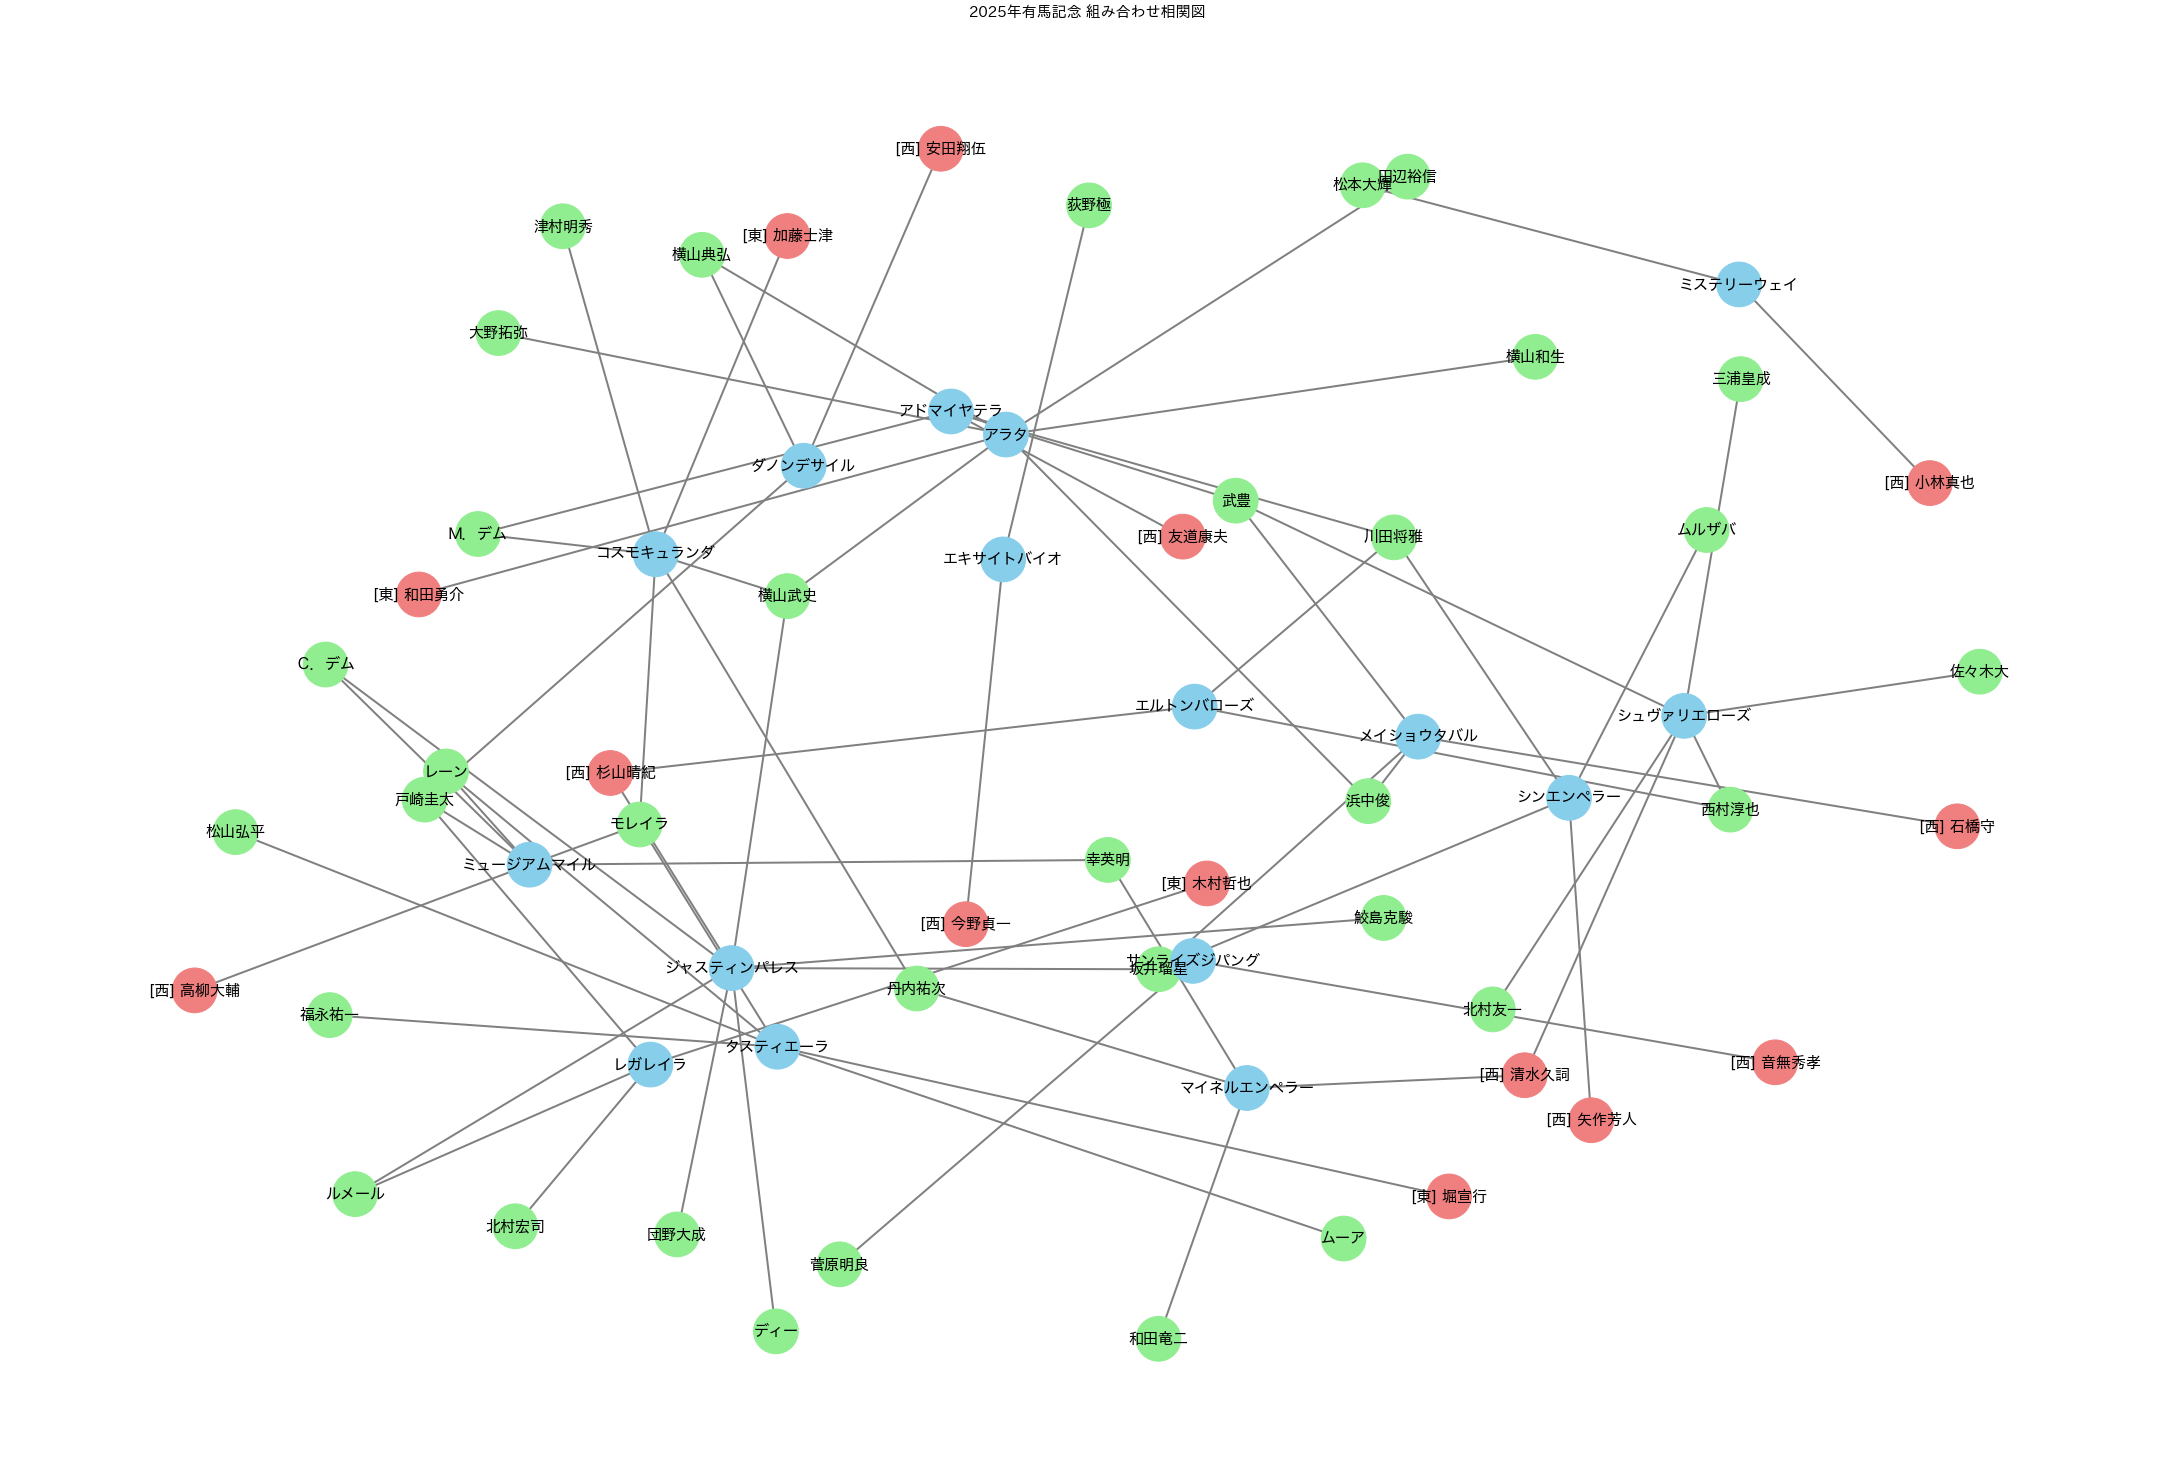

In [122]:
G = nx.Graph()

for _, row in filtered_df.iterrows():
    # 調教師 --- 馬
    G.add_edge(row['調教師'], row['馬名'])
    # 馬 --- 騎手
    G.add_edge(row['馬名'], row['騎手'])

plt.figure(figsize=(30, 20))
pos = nx.spring_layout(G, k=0.6, seed=42)
node_colors = []
for node in G.nodes():
    if node in filtered_df['調教師'].values:
        node_colors.append('lightcoral')  # 調教師は赤系
    elif node in filtered_df['騎手'].values:
        node_colors.append('lightgreen')  # 騎手は緑系
    else:
        node_colors.append('skyblue')     # 馬は青系
nx.draw(G, pos, 
        with_labels=True, 
        node_color=node_colors, 
        node_size=2000, 
        font_size=15, 
        font_family='Hiragino Sans', # Windowsの場合。Macなら'Hiragino Sans'など
        edge_color='gray',
        width=2.0)

plt.title("2025年有馬記念 組み合わせ相関図", fontsize=15)
plt.show()

In [123]:
sub = filtered_df[filtered_df['馬名']=='レガレイラ']

In [124]:
sub['course_len'].unique()

array([2200, 2500, 2000, 2400])

In [125]:
df.columns

Index(['着順', '枠番', '馬番', '馬名', '性齢', '斤量', '騎手', 'タイム', '着差', '単勝', '人気',
       '馬体重', '調教師', 'course_len', 'weather', 'race_type', 'ground_state',
       'date', 'horse_id', 'jockey_id'],
      dtype='object')

In [166]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. データの前処理 (df はお手持ちのDataFrameとします)
# ---------------------------------------------------------

# コピーを作成して作業
df_model = df.copy()

# (1) 目的変数の確認 (3着以内なら1, それ以外0)
# すでに 'Target' があるとのことですが、念のため定義を明確にします
# もし '着順' が数値でない場合（'取消'など）の処理が必要です
df_model['Rank_Num'] = pd.to_numeric(df_model['着順'], errors='coerce')
df_model['Target_Top3'] = df_model['Rank_Num'].apply(lambda x: 1 if x <= 3 else 0)

# (2) 性齢の分解 (例: "牡3" -> 性別:牡, 年齢:3)
# 多くのデータセットで "性齢" は結合されています。分解して数値/カテゴリ化します。
df_model['Sex'] = df_model['性齢'].str[0] # 最初の1文字
df_model['Age'] = df_model['性齢'].str[1:].astype(int) # 残りの数字

# 性別をダミー変数化 (牡=1, 牝=0, セン=0 とするなど。ここではシンプルに牡馬か否か)
df_model['Is_Male'] = df_model['Sex'].apply(lambda x: 1 if x == '牡' else 0)

# (3) Target Encoding (騎手・調教師の「腕前」を数値化)
# 注意: リークを防ぐため、本来は「過去のデータ」のみで計算すべきですが、
# ここでは簡易的に全データの平均を使います（実戦では時系列に注意）。

# 騎手の複勝率を計算
jockey_stats = df_model.groupby('騎手')['Target_Top3'].mean().reset_index()
jockey_stats.columns = ['騎手', 'Jockey_Rate']

# 調教師の複勝率を計算
trainer_stats = df_model.groupby('調教師')['Target_Top3'].mean().reset_index()
trainer_stats.columns = ['調教師', 'Trainer_Rate']

horse_stats = df_model.groupby('馬名')['Target_Top3'].mean().reset_index()
horse_stats.columns = ['馬名', 'Horse_Rate']

# 元データに結合（これで「名前」が「数値」に変わります！）
df_model = pd.merge(df_model, jockey_stats, on='騎手', how='left')
df_model = pd.merge(df_model, trainer_stats, on='調教師', how='left')
df_model = pd.merge(df_model, horse_stats, on = '馬名', how='left')

# (4) その他、数値化が必要なもの
# course_len は数値型になっていると仮定
# 斤量 も数値型になっていると仮定

# ---------------------------------------------------------
# 2. ロジスティック回帰モデルの構築
# ---------------------------------------------------------
# 説明変数:
# - Jockey_Rate: 騎手の強さ（数値）
# - Trainer_Rate: 調教師の強さ（数値）
# - 斤量: 負担重量
# - Age: 馬の年齢
# - course_len: 距離（必要に応じて）
# - 枠番: 内枠有利などを捉える

# formula = """
# Target_Top3 ~ Jockey_Rate + Trainer_Rate + Horse_Rate + 斤量 + Age + Is_Male + course_len + 枠番 + weather + ground_state
# """

# # モデル作成
# model = smf.logit(formula, data=df_model)
# result = model.fit()

# # ---------------------------------------------------------
# # 3. 結果の解釈 (オッズ比)
# # ---------------------------------------------------------
# print(result.summary())

# # オッズ比の計算 (係数の指数をとる)
# odds_ratios = np.exp(result.params)
# conf = np.exp(result.conf_int())
# conf.columns = ['95%CI Lower', '95%CI Upper']
# summary_or = pd.DataFrame({'Odds Ratio': odds_ratios}).join(conf)

# print("\n=== オッズ比 (Odds Ratios) ===")
# print(summary_or)

from sklearn.preprocessing import StandardScaler

# 数値データのリスト
cols_to_scale = ['斤量', 'Age', 'course_len', 'Jockey_Rate', 'Trainer_Rate', 'Horse_Rate', '枠番']

# データのコピー
df_scaled = df_model.copy() # subは元のデータフレーム

# 標準化（平均0, 分散1に変換）
scaler = StandardScaler()
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

# モデル再構築
logit_model_scaled = smf.logit("""Target_Top3 ~ C(weather, Treatment(reference='曇')) + 
                                           C(ground_state, Treatment(reference='良')) + 
                                           Is_Male + 
                                           斤量 + Age + course_len + 枠番 + 
                                           Jockey_Rate + Trainer_Rate + Horse_Rate
                                """, data=df_scaled)
result_scaled = logit_model_scaled.fit()

# 結果表示
print(result_scaled.summary())

Optimization terminated successfully.
         Current function value: 0.324318
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            Target_Top3   No. Observations:                 8602
Model:                          Logit   Df Residuals:                     8586
Method:                           MLE   Df Model:                           15
Date:                Fri, 26 Dec 2025   Pseudo R-squ.:                  0.3528
Time:                        12:08:19   Log-Likelihood:                -2789.8
converged:                       True   LL-Null:                       -4310.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                         

In [167]:
# これを実行すると、以降のPandasの出力が「小数点以下6桁」の普通の数字になります
pd.options.display.float_format = '{:.6f}'.format

# 確認
print("\n=== オッズ比 (普通の数字で表示) ===")
print(summary_or)


=== オッズ比 (普通の数字で表示) ===
                       Odds Ratio  95%CI Lower     95%CI Upper
Intercept          1776190.821042 45096.062390 69958521.110717
weather[T.晴]             0.996400     0.701017        1.416245
weather[T.曇]             0.968934     0.679432        1.381791
weather[T.雨]             0.925436     0.532828        1.607333
ground_state[T.稍重]       0.531710     0.271304        1.042064
ground_state[T.良]        0.487906     0.251305        0.947263
ground_state[T.重]        0.573452     0.287558        1.143588
Jockey_Rate             10.962193     5.287271       22.728110
Trainer_Rate             1.165416     0.422864        3.211891
Horse_Rate            1393.832780   903.939605     2149.225243
斤量                       0.732782     0.685148        0.783727
Age                      0.980236     0.930556        1.032568
Is_Male                  1.870535     1.535395        2.278830
course_len               0.999791     0.999622        0.999960
枠番                       0.963

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 2025年有馬記念 出走馬リスト (枠順確定版)
# 医学的視点: ここが「新規患者データ」の入力になります
arima_2025_entries = [
    {'枠番': 1, '馬番': 1, '馬名': 'エキサイトバイオ',   '性齢': '牡3', '斤量': 56, '騎手': '荻野極',     '調教師': '今野貞一'},
    {'枠番': 1, '馬番': 2, '馬名': 'シンエンペラー',     '性齢': '牡4', '斤量': 58, '騎手': '坂井瑠星',   '調教師': '矢作芳人'},
    {'枠番': 2, '馬番': 3, '馬名': 'ジャスティンパレス', '性齢': '牡6', '斤量': 58, '騎手': '団野大成',   '調教師': '杉山晴紀'},
    {'枠番': 2, '馬番': 4, '馬名': 'ミュージアムマイル', '性齢': '牡3', '斤量': 56, '騎手': 'C.デムーロ', '調教師': '高柳大輔'},
    {'枠番': 3, '馬番': 5, '馬名': 'レガレイラ',         '性齢': '牝4', '斤量': 56, '騎手': 'C.ルメール', '調教師': '木村哲也'},
    {'枠番': 3, '馬番': 6, '馬名': 'メイショウタバル',   '性齢': '牡4', '斤量': 58, '騎手': '武豊',       '調教師': '石橋守'},
    {'枠番': 4, '馬番': 7, '馬名': 'サンライズジパング', '性齢': '牡4', '斤量': 58, '騎手': '鮫島克駿',   '調教師': '前川恭子'},
    {'枠番': 4, '馬番': 8, '馬名': 'シュヴァリエローズ', '性齢': '牡7', '斤量': 58, '騎手': '北村友一',   '調教師': '清水久詞'},
    {'枠番': 5, '馬番': 9, '馬名': 'ダノンデサイル',     '性齢': '牡4', '斤量': 58, '騎手': '戸崎圭太',   '調教師': '安田翔伍'},
    {'枠番': 5, '馬番': 10, '馬名': 'コスモキュランダ',   '性齢': '牡4', '斤量': 58, '騎手': '横山武史',   '調教師': '加藤士津八'},
    {'枠番': 6, '馬番': 11, '馬名': 'ミステリーウェイ',   '性齢': '牡5', '斤量': 58, '騎手': '松本大輝',   '調教師': '小林真也'}, # 年齢推定
    {'枠番': 6, '馬番': 12, '馬名': 'マイネルエンペラー', '性齢': '牡5', '斤量': 58, '騎手': '丹内祐次',   '調教師': '清水久詞'}, # 年齢推定
    {'枠番': 7, '馬番': 13, '馬名': 'アドマイヤテラ',     '性齢': '牡3', '斤量': 56, '騎手': '川田将雅',   '調教師': '友道康夫'},
    {'枠番': 7, '馬番': 14, '馬名': 'アラタ',             '性齢': '牡8', '斤量': 58, '騎手': '大野拓弥',   '調教師': '和田勇介'},
    {'枠番': 8, '馬番': 15, '馬名': 'エルトンバローズ',   '性齢': '牡5', '斤量': 58, '騎手': '西村淳也',   '調教師': '杉山晴紀'},
    {'枠番': 8, '馬番': 16, '馬名': 'タスティエーラ',     '性齢': '牡5', '斤量': 58, '騎手': '松山弘平',   '調教師': '堀宣行'}
]

df_arima = pd.DataFrame(arima_2025_entries)

# 2. 特徴量エンジニアリング (学習時と同じ処理を適用)
# 性別・年齢の分解
df_arima['Sex'] = df_arima['性齢'].str[0]
df_arima['Age'] = df_arima['性齢'].str[1:].astype(int)
df_arima['Is_Male'] = df_arima['Sex'].apply(lambda x: 1 if x == '牡' else 0)
df_arima['course_len'] = 2500  # 有馬記念の距離
df_arima['weather']='晴'
df_arima['ground_state']='良'

# 3. 騎手・調教師データの結合 (Target Encoding)
# 学習データ(df_model)から作成した stats を使用します
# 外部結合(left join)し、新規騎手などでデータがない場合は平均値で埋めます (Imputation)

# 前のターンで作成した jockey_stats, trainer_stats を使用
df_arima = pd.merge(df_arima, jockey_stats, on='騎手', how='left')
df_arima = pd.merge(df_arima, trainer_stats, on='調教師', how='left')
df_arima = pd.merge(df_arima, horse_stats, on='馬名', how='left')

# 欠損値補完 (未知の騎手/調教師は「平均的な実力」と仮定)
avg_jockey_rate = df_model['Jockey_Rate'].mean()
avg_trainer_rate = df_model['Trainer_Rate'].mean()
avg_horse_rate = df_model['Horse_Rate'].mean()

df_arima['Jockey_Rate'] = df_arima['Jockey_Rate'].fillna(avg_jockey_rate)
df_arima['Trainer_Rate'] = df_arima['Trainer_Rate'].fillna(avg_trainer_rate)
df_arima['Horse_Rate'] = df_arima['Horse_Rate'].fillna(avg_horse_rate)

# 4. 予測の実行 (Predict)
# ロジスティック回帰モデルに適用
df_arima['Prob_Top3'] = result.predict(df_arima)

# 5. 結果の表示
result_ranking = df_arima[['枠番', '馬番', '馬名', '騎手', 'Prob_Top3']].sort_values('Prob_Top3', ascending=False)
result_ranking['Prob_Top3'] = result_ranking['Prob_Top3'].apply(lambda x: f"{x:.1%}") # パーセント表示

print("=== 2025年 有馬記念 AI好走確率予測 (Top 8) ===")
print(result_ranking.head(8))

=== 2025年 有馬記念 AI好走確率予測 (Top 8) ===
    枠番  馬番         馬名      騎手 Prob_Top3
0    1   1   エキサイトバイオ     荻野極     98.2%
10   6  11   ミステリーウェイ    松本大輝     98.0%
3    2   4  ミュージアムマイル  C.デムーロ     82.7%
8    5   9    ダノンデサイル    戸崎圭太     80.4%
1    1   2    シンエンペラー    坂井瑠星     73.8%
12   7  13    アドマイヤテラ    川田将雅     50.6%
14   8  15   エルトンバローズ    西村淳也     38.4%
11   6  12  マイネルエンペラー    丹内祐次     38.3%


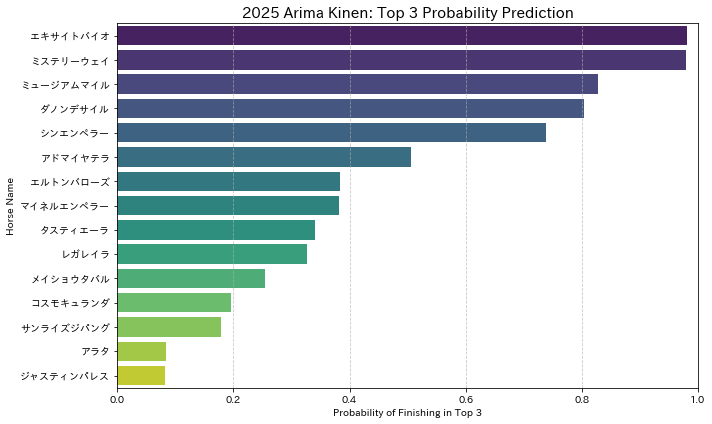

In [170]:
# 上位馬の確率をグラフ化
top_horses = df_arima.sort_values('Prob_Top3', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Prob_Top3', y='馬名', data=top_horses, palette='viridis')
plt.title('2025 Arima Kinen: Top 3 Probability Prediction', fontsize=15)
plt.xlabel('Probability of Finishing in Top 3')
plt.ylabel('Horse Name')
plt.xlim(0, 1)  # 確率は0~1の間
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 過学習をできるだけベイズ平均化して防いでいる

#### この状態だとG1からG3まで混ざっているため、ウェイトをつける必要がある

In [190]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# 数値表示を見やすく設定
pd.options.display.float_format = '{:.4f}'.format

# ---------------------------------------------------------
# 1. ベイズ平滑化関数の定義 (過学習防止のコアロジック)
# ---------------------------------------------------------
# 「1戦1勝の馬」を過大評価せず、データが少ない場合は全体平均に引き寄せる処理
def calculate_bayesian_rate(df, group_col, target_col='Target_Top3', C=20):
    global_mean = df[target_col].mean()
    stats = df.groupby(group_col)[target_col].agg(['sum', 'count'])
    # ベイズ平均 = (成功数 + C * 全体平均) / (試行回数 + C)
    stats['Bayes_Rate'] = (stats['sum'] + C * global_mean) / (stats['count'] + C)
    return stats[['Bayes_Rate']]

# ---------------------------------------------------------
# 2. 学習データの作成と前処理
# ---------------------------------------------------------
print("--- Preprocessing Training Data ---")
df_model = df.copy()

# (1) 目的変数の作成 (3着以内=1)
df_model['Rank_Num'] = pd.to_numeric(df_model['着順'], errors='coerce')
df_model['Target_Top3'] = df_model['Rank_Num'].apply(lambda x: 1 if x <= 3 else 0)

# (2) 性齢の分解
df_model['Sex'] = df_model['性齢'].str[0]
df_model['Age'] = df_model['性齢'].str[1:].astype(int)
df_model['Is_Male'] = df_model['Sex'].apply(lambda x: 1 if x == '牡' else 0)

# (3) ベイズレートの計算と結合
# Cの値が大きいほど、過去データが少ない時の信頼度を低く見積もります
jockey_bayes = calculate_bayesian_rate(df_model, '騎手', C=20)
trainer_bayes = calculate_bayesian_rate(df_model, '調教師', C=20)
horse_bayes = calculate_bayesian_rate(df_model, '馬名', C=5) # 馬はサンプルが少ないのでC=5程度

# カラム名変更
jockey_bayes.columns = ['Jockey_Rate']
trainer_bayes.columns = ['Trainer_Rate']
horse_bayes.columns = ['Horse_Rate']

# 結合
df_model = pd.merge(df_model, jockey_bayes, on='騎手', how='left')
df_model = pd.merge(df_model, trainer_bayes, on='調教師', how='left')
df_model = pd.merge(df_model, horse_bayes, on='馬名', how='left')

# 欠損値（新規の騎手など）は全体平均で埋める
global_mean = df_model['Target_Top3'].mean()
df_model['Jockey_Rate'] = df_model['Jockey_Rate'].fillna(global_mean)
df_model['Trainer_Rate'] = df_model['Trainer_Rate'].fillna(global_mean)
df_model['Horse_Rate'] = df_model['Horse_Rate'].fillna(global_mean)

# ---------------------------------------------------------
# 3. 標準化とモデル構築
# ---------------------------------------------------------
print("--- Training Logistic Regression Model ---")

# 標準化する変数のリスト
cols_to_scale = ['斤量', 'Age', 'course_len', 'Jockey_Rate', 'Trainer_Rate', 'Horse_Rate', '枠番']

# スケーラーの準備 (学習データの統計量で定義)
scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

# モデル式 (weather, ground_stateはダミー変数として扱うためC()で囲む)
formula = """Target_Top3 ~ C(weather, Treatment(reference='曇')) + 
                           C(ground_state, Treatment(reference='良')) + 
                           Is_Male + 
                           斤量 + Age + course_len + 枠番 + 
                           Jockey_Rate + Trainer_Rate + Horse_Rate"""

model = smf.logit(formula, data=df_scaled)
result = model.fit(disp=0) # disp=0で途中経過を非表示

# オッズ比の表示
odds_ratios = np.exp(result.params)
print("\n=== Odds Ratios (Significant Factors) ===")
print(odds_ratios.sort_values(ascending=False).head(5))

# ---------------------------------------------------------
# 4. 2025年有馬記念の予測 (Inference)
# ---------------------------------------------------------
print("\n--- Predicting Arima Kinen 2025 ---")

# (1) 出走馬データ定義
arima_2025_entries = [
    {'枠番': 1, '馬番': 1, '馬名': 'エキサイトバイオ',   '性齢': '牡3', '斤量': 56, '騎手': '荻野極',     '調教師': '今野貞一'},
    {'枠番': 1, '馬番': 2, '馬名': 'シンエンペラー',     '性齢': '牡4', '斤量': 58, '騎手': '坂井瑠星',   '調教師': '矢作芳人'},
    {'枠番': 2, '馬番': 3, '馬名': 'ジャスティンパレス', '性齢': '牡6', '斤量': 58, '騎手': '団野大成',   '調教師': '杉山晴紀'},
    {'枠番': 2, '馬番': 4, '馬名': 'ミュージアムマイル', '性齢': '牡3', '斤量': 56, '騎手': 'C.デムーロ', '調教師': '高柳大輔'},
    {'枠番': 3, '馬番': 5, '馬名': 'レガレイラ',         '性齢': '牝4', '斤量': 56, '騎手': 'C.ルメール', '調教師': '木村哲也'},
    {'枠番': 3, '馬番': 6, '馬名': 'メイショウタバル',   '性齢': '牡4', '斤量': 58, '騎手': '武豊',       '調教師': '石橋守'},
    {'枠番': 4, '馬番': 7, '馬名': 'サンライズジパング', '性齢': '牡4', '斤量': 58, '騎手': '鮫島克駿',   '調教師': '前川恭子'},
    {'枠番': 4, '馬番': 8, '馬名': 'シュヴァリエローズ', '性齢': '牡7', '斤量': 58, '騎手': '北村友一',   '調教師': '清水久詞'},
    {'枠番': 5, '馬番': 9, '馬名': 'ダノンデサイル',     '性齢': '牡4', '斤量': 58, '騎手': '戸崎圭太',   '調教師': '安田翔伍'},
    {'枠番': 5, '馬番': 10, '馬名': 'コスモキュランダ',   '性齢': '牡4', '斤量': 58, '騎手': '横山武史',   '調教師': '加藤士津八'},
    {'枠番': 6, '馬番': 11, '馬名': 'ミステリーウェイ',   '性齢': 'セ7', '斤量': 58, '騎手': '松本大輝',   '調教師': '小林真也'},
    {'枠番': 6, '馬番': 12, '馬名': 'マイネルエンペラー', '性齢': '牡5', '斤量': 58, '騎手': '丹内祐次',   '調教師': '清水久詞'},
    {'枠番': 7, '馬番': 13, '馬名': 'アドマイヤテラ',     '性齢': '牡3', '斤量': 56, '騎手': '川田将雅',   '調教師': '友道康夫'},
    {'枠番': 7, '馬番': 14, '馬名': 'アラタ',             '性齢': '牡8', '斤量': 58, '騎手': '大野拓弥',   '調教師': '和田勇介'},
    {'枠番': 8, '馬番': 15, '馬名': 'エルトンバローズ',   '性齢': '牡5', '斤量': 58, '騎手': '西村淳也',   '調教師': '杉山晴紀'},
    {'枠番': 8, '馬番': 16, '馬名': 'タスティエーラ',     '性齢': '牡5', '斤量': 58, '騎手': '松山弘平',   '調教師': '堀宣行'}
]

df_arima = pd.DataFrame(arima_2025_entries)

# (2) 前処理（学習データと同じ処理）
df_arima['Sex'] = df_arima['性齢'].str[0]
df_arima['Age'] = df_arima['性齢'].str[1:].astype(int)
df_arima['Is_Male'] = df_arima['Sex'].apply(lambda x: 1 if x == '牡' else 0)
df_arima['course_len'] = 2500  # 有馬記念の条件
df_arima['weather'] = '晴'     # 当日の想定
df_arima['ground_state'] = '良' # 当日の想定

# (3) ベイズレートのマッピング (ここが重要)
df_arima = pd.merge(df_arima, jockey_bayes, on='騎手', how='left')
df_arima = pd.merge(df_arima, trainer_bayes, on='調教師', how='left')
df_arima = pd.merge(df_arima, horse_bayes, on='馬名', how='left')

# 欠損値（初出走馬など）は全体平均で埋める
df_arima['Jockey_Rate'] = df_arima['Jockey_Rate'].fillna(global_mean)
df_arima['Trainer_Rate'] = df_arima['Trainer_Rate'].fillna(global_mean)
df_arima['Horse_Rate'] = df_arima['Horse_Rate'].fillna(global_mean)

# (4) 標準化 (transformのみ実行)
df_arima_scaled = df_arima.copy()
df_arima_scaled[cols_to_scale] = scaler.transform(df_arima_scaled[cols_to_scale])

# (5) 確率予測
df_arima['Win_Probability'] = result.predict(df_arima_scaled)

# 結果出力
ranking = df_arima[['枠番', '馬番', '馬名', '騎手', 'Win_Probability']].sort_values('Win_Probability', ascending=False)
ranking['Win_Probability'] = ranking['Win_Probability'].apply(lambda x: f"{x:.2%}")

print("\n=== 最終予測結果: 2025年有馬記念 ===")
print(ranking.to_string(index=False))

--- Preprocessing Training Data ---
--- Training Logistic Regression Model ---

=== Odds Ratios (Significant Factors) ===
Horse_Rate                                        4.0602
C(weather, Treatment(reference='曇'))[T.小雪]        2.9752
Is_Male                                           1.7642
C(ground_state, Treatment(reference='良'))[T.不良]   1.2797
Jockey_Rate                                       1.2669
dtype: float64

--- Predicting Arima Kinen 2025 ---

=== 最終予測結果: 2025年有馬記念 ===
 枠番  馬番        馬名     騎手 Win_Probability
  5   9   ダノンデサイル   戸崎圭太          85.33%
  2   4 ミュージアムマイル C.デムーロ          82.74%
  1   1  エキサイトバイオ    荻野極          76.60%
  1   2   シンエンペラー   坂井瑠星          73.92%
  7  13   アドマイヤテラ   川田将雅          50.64%
  8  15  エルトンバローズ   西村淳也          49.76%
  8  16   タスティエーラ   松山弘平          43.57%
  3   5     レガレイラ C.ルメール          40.07%
  3   6  メイショウタバル     武豊          32.67%
  6  12 マイネルエンペラー   丹内祐次          27.86%
  5  10  コスモキュランダ   横山武史          25.84%
  6  11  ミステリーウェイ   松本

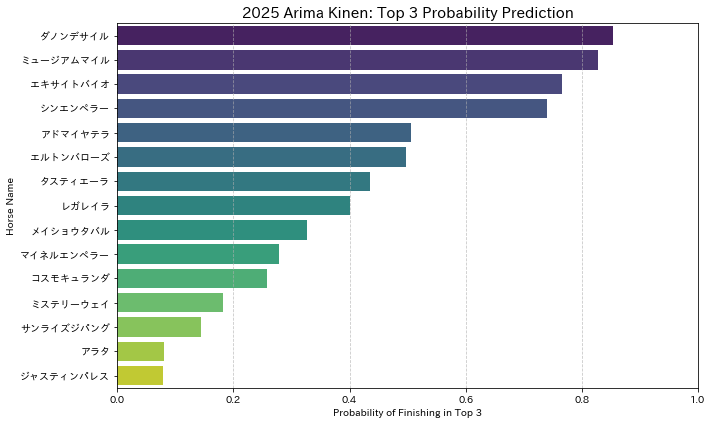

In [191]:
# 上位馬の確率をグラフ化
top_horses = df_arima.sort_values('Win_Probability', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Win_Probability', y='馬名', data=top_horses, palette='viridis')
plt.title('2025 Arima Kinen: Top 3 Probability Prediction', fontsize=15)
plt.xlabel('Probability of Finishing in Top 3')
plt.ylabel('Horse Name')
plt.xlim(0, 1)  # 確率は0~1の間
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [193]:
df.head(5)

,着順,枠番,馬番,馬名,性齢,斤量,騎手,タイム,着差,単勝,人気,馬体重,調教師,course_len,weather,race_type,ground_state,date,horse_id,jockey_id
202506050111,1,3,3,ホーエリート,牝4,55.0000,戸崎圭太,3:47.2,NaN,4.4000,2.0000,476(-6),[東] 田島俊明,3600,晴,芝,良,2025年12月06日,2021104855,05386
202506050111,2,3,4,マイネルカンパーナ,牡5,57.0000,津村明秀,3:47.3,3/4,11.6000,5.0000,414(+2),[東] 青木孝文,3600,晴,芝,良,2025年12月06日,2020105798,01092
202506050111,3,5,7,クロミナンス,牡8,57.0000,ルメール,3:47.3,ハナ,3.5000,1.0000,494(0),[東] 尾関知人,3600,晴,芝,良,2025年12月06日,2017105074,05339
202506050111,4,5,8,ブレイヴロッカー,セ5,57.0000,荻野極,3:47.3,クビ,18.3000,9.0000,456(+2),[西] 本田優,3600,晴,芝,良,2025年12月06日,2020102870,01160
202506050111,5,7,12,ワープスピード,牡6,57.0000,菅原明良,3:47.5,3/4,18.0000,8.0000,504(+6),[東] 高木登,3600,晴,芝,良,2025年12月06日,2019105312,01179


In [194]:
### 下馬評的にもミュージアムマイルかダノンデサイルあたりが強そう